In [1]:
import pandas as pd 
df = pd.read_csv("../data/processed/matches_features_v1.csv")
df.head(1)



,team1,team2,venue,toss_winner,toss_decision,winner,date,team1_matches_played,team1_win_rate,team1_form_5,...,team2_win_rate,team2_form_5,team1_h2h_wins,team2_h2h_wins,team1_venue_matches,team1_venue_win_rate,team2_venue_matches,team2_venue_win_rate,team1_won_toss,team2_won_toss
0,New Zealand,Australia,Eden Park,Australia,1,Australia,2005-02-17,0,0.0,0,...,0.0,0,0,0,0,0.0,0,0.0,0,1


In [2]:
X = df.drop(["winner","date"], axis=1)
y = df["winner"]


In [3]:
from sklearn.model_selection import train_test_split as tts 

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

print(df.iloc[:split_idx]["date"].min())
print(df.iloc[:split_idx]["date"].max())

print(df.iloc[split_idx:]["date"].min())
print(df.iloc[split_idx:]["date"].max())

(4188, 19)
(1047, 19)
2005-02-17
2025-06-18
2025-06-19
2026-06-09


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

categorical_features = ["team1", "team2","venue","toss_decision","toss_winner"]

numerical_features = ["team1_matches_played",
                      "team1_win_rate",
                      "team1_form_5",

    "team2_matches_played",
    "team2_win_rate",
    "team2_form_5",

    "team1_h2h_wins",
    "team2_h2h_wins",

    "team1_venue_matches",
    "team1_venue_win_rate",

    "team2_venue_matches",
    "team2_venue_win_rate",

    "team1_won_toss",
    "team2_won_toss"
    ]




In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat", OneHotEncoder(handle_unknown="ignore"),categorical_features,
            
        ),
        (
            "num", StandardScaler(), numerical_features
        )
    ],
    remainder="passthrough"
)

    


In [6]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
           max_iter= 1000,
           random_state=42
        ))
    ]
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score 
from sklearn.metrics import classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print("accuracy is ", accuracy)
print(classification_report(y_test, y_pred))
# con = confusion_matrix(y_test,y_pred)
# print(con)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.show()

correct = (y_test == y_pred).sum()
incorrect = (y_test != y_pred).sum()

print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {incorrect}")

accuracy is  0.6609360076408787
                          precision    recall  f1-score   support

               Argentina       1.00      0.67      0.80         6
               Australia       0.64      1.00      0.78        16
                 Austria       0.69      0.82      0.75        22
                 Bahrain       0.69      0.89      0.78        28
              Bangladesh       0.82      0.70      0.76        20
                 Belgium       0.50      0.50      0.50         2
                 Bermuda       0.50      1.00      0.67         1
                  Bhutan       0.75      0.30      0.43        10
                Botswana       0.58      0.94      0.71        16
                  Brazil       0.50      0.23      0.32        13
                Bulgaria       0.60      0.60      0.60         5
                Cambodia       0.00      0.00      0.00         0
                Cameroon       0.00      0.00      0.00         6
                  Canada       0.60      1.

C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_cla

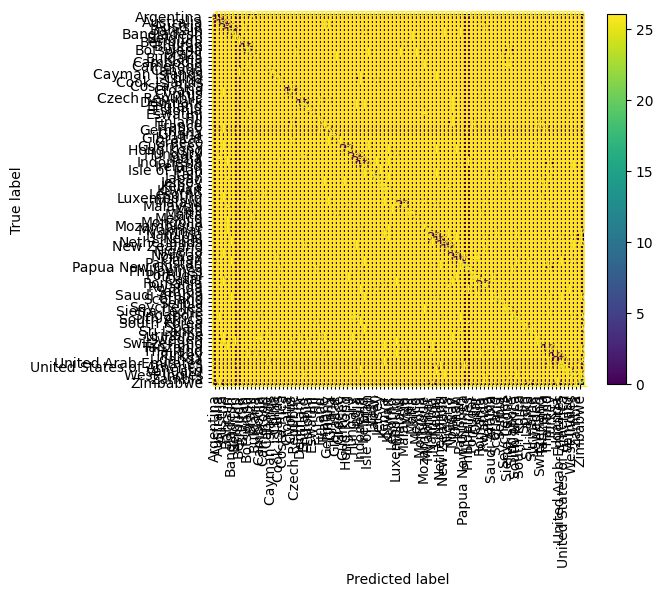

Correct predictions: 692
Incorrect predictions: 355


In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.show()

correct = (y_test == y_pred).sum()
incorrect = (y_test != y_pred).sum()

print(f"Correct predictions: {correct}")
print(f"Incorrect predictions: {incorrect}")

In [8]:
rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=500,
                max_depth=15,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
        ))
        ]
)
rf_pipeline.fit(X_train,y_train)
y_pred_rf = rf_pipeline.predict(X_test)


In [9]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(classification_report(y_test, y_pred_rf))
print("Accuracy is ",accuracy)

                          precision    recall  f1-score   support

               Argentina       0.00      0.00      0.00         6
               Australia       0.60      0.94      0.73        16
                 Austria       0.78      0.82      0.80        22
                 Bahrain       0.85      0.39      0.54        28
              Bangladesh       0.77      0.50      0.61        20
                 Belgium       0.00      0.00      0.00         2
                 Bermuda       0.50      1.00      0.67         1
                  Bhutan       0.00      0.00      0.00        10
                Botswana       1.00      0.50      0.67        16
                  Brazil       0.00      0.00      0.00        13
                Bulgaria       0.00      0.00      0.00         5
                Cambodia       0.00      0.00      0.00         0
                Cameroon       0.00      0.00      0.00         6
                  Canada       1.00      1.00      1.00         3
         

C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SURYANSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_cla